# Stochastic Interest Rate Modelling and Prediction

## Project Objective

This project aims to calibrate and evaluate the Cox-Ingersoll-Ross (CIR) interest-rate model using Treasury yield curve data.

The objectives are:

- Calibrate a single-factor CIR model using short-rate observations.
- Reconstruct the full yield curve from the short-rate process.
- Evaluate in-sample and out-of-sample performance.
- Investigate the impact of calibration methodology.
- Extend the model using a two-factor CIR specification.
- Compare the predictive performance of the base and extended models.



## 1. Data engineering and preproceesing


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize, differential_evolution
from scipy.stats import ncx2
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

plt.style.use("default")
plt.rcParams["figure.figsize"]=(10,5)

**Dataset Description**

The dataset consists of Treasury zero-coupon yields observed across multiple maturities ranging from 3 months to 30 years.

The data is divided into:

- Training set (used for calibration)
- Test set (used for out-of-sample evaluation)

The 3-month Treasury yield is used as a proxy for the instantaneous short rate required by the CIR framework.

In [ ]:
train=pd.read_csv("data/train_data.csv")
test=pd.read_csv("data/test_data.csv")
test_3m=pd.read_csv("data/test_data_3M.csv")

print(train.shape)
print(test.shape)
print(test_3m.shape)

(1976, 10)
(495, 6)
(495, 2)


In [4]:
train.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [5]:
rename_col={
" ZC025YR":"3M",
" ZC050YR":"6M",
" ZC075YR":"9M",
" ZC100YR":"1Y",
" ZC200YR":"2Y",
" ZC500YR":"5Y",
" ZC1000YR":"10Y",
" ZC2000YR":"20Y",
" ZC3000YR":"30Y"
}

train=train.rename(columns=rename_col)
test=test.rename(columns=rename_col)
test_3m=test_3m.rename(columns=rename_col)

In [6]:
for df in [train,test,test_3m]:
    df["Date"]=pd.to_datetime(df["Date"])
    df.sort_values("Date",inplace=True)
    df.reset_index(drop=True,inplace=True)

In [7]:
mats=["3M","6M","9M","1Y","2Y","5Y","10Y","20Y","30Y"]

In [8]:
train.head()

,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [9]:
train[mats].describe().T

,count,mean,std,min,25%,50%,75%,max
3M,1976.0,0.016699,0.016642,0.000486,0.004621,0.011912,0.017112,0.051962
6M,1976.0,0.017885,0.016760,0.000878,0.005190,0.013815,0.019378,0.053195
9M,1976.0,0.018529,0.016650,0.001054,0.005449,0.015304,0.021077,0.054040
1Y,1976.0,0.019174,0.016587,0.001227,0.005729,0.016335,0.022743,0.054941
2Y,1976.0,0.018063,0.013661,0.001417,0.005897,0.015471,0.025553,0.048496
5Y,1976.0,0.018109,0.010396,0.002786,0.009570,0.015981,0.026415,0.043147
10Y,1976.0,0.020226,0.008805,0.004451,0.014451,0.018905,0.027340,0.042232
20Y,1976.0,0.022823,0.007136,0.008394,0.017739,0.022472,0.028148,0.040687
30Y,1976.0,0.022619,0.006601,0.006921,0.017895,0.022258,0.027408,0.039306


Implication for CIR Modelling:

The presence of higher volatility at shorter maturities supports the use of a short-rate framework, since movements in the short end of the curve are expected to propagate through the term structure.

In [10]:
# Missing values
train.isna().sum()

,0
Date,0
3M,0
6M,0
9M,0
1Y,0
2Y,0
5Y,0
10Y,0
20Y,0
30Y,0


No missing values were detected. Consequently, no imputation procedure was required and all observations were retained for calibration.

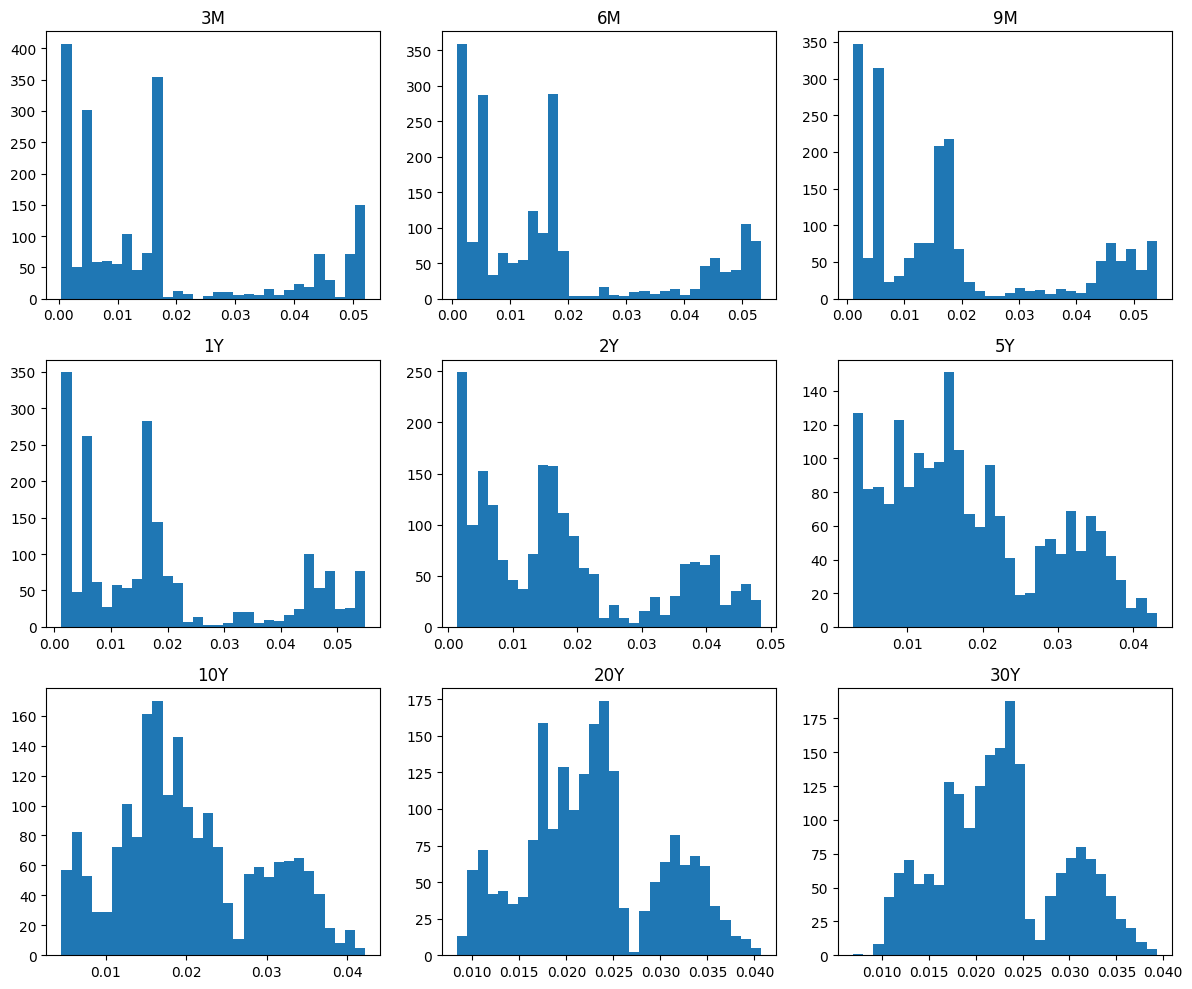

,0
3M,1.065002
6M,0.988827
9M,0.942129
1Y,0.891344
2Y,0.706427
5Y,0.483397
10Y,0.360715
20Y,0.221612
30Y,0.241481


In [11]:
# Distribution analysis
fig,axes=plt.subplots(3,3,figsize=(12,10))
axes=axes.flatten()
for i,col in enumerate(mats):
    axes[i].hist(train[col],bins=30)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

train[mats].skew()

Short-term maturities exhibit positive skewness, indicating occasional upward spikes in interest rates. This behaviour is consistent with the asymmetric volatility structure of the CIR process, where volatility increases with the level of rates.


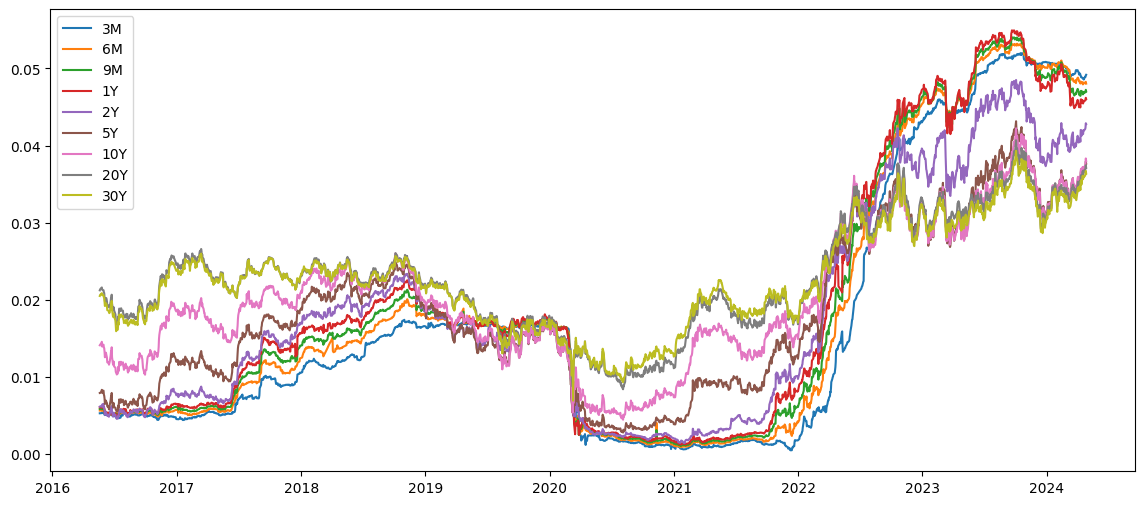

In [12]:
# Time series evolution
plt.figure(figsize=(14,6))
for col in mats:
    plt.plot(train["Date"],train[col],label=col)
plt.legend()
plt.show()

The yield series display strong persistence over time and clear regime-based behaviour, rather than moving in a completely random manner. Periods of low and high interest rates tend to persist for extended durations, showing that rates evolve gradually and retain memory of past market conditions.

The persistence observed in the series provides empirical motivation for estimating a mean-reversion parameter κ rather than assuming independent observations.


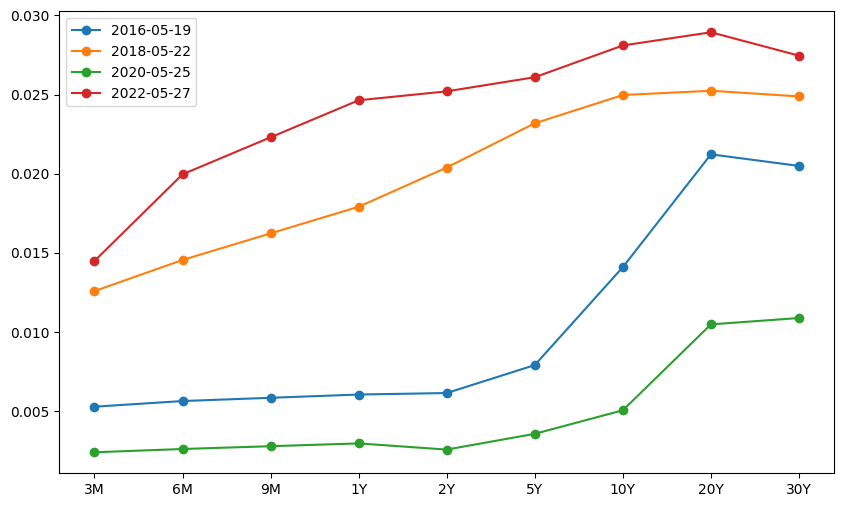

In [13]:
# Yield Curve Shape Through Time
samples=[0,500,1000,1500]
plt.figure(figsize=(10,6))
for s in samples:
    plt.plot(mats,train.loc[s,mats],marker="o",label=str(train.Date.iloc[s])[:10])
plt.legend()
plt.show()

The term structure changes noticeably over time, shifting between steeper and flatter yield curve shapes under different market conditions. Despite these changes, the curves remain smooth across maturities, showing that yields at neighbouring maturities are strongly related and tend to move together.

The fact that the yield curve changes shape through time suggests that a single factor may not always be sufficient to explain all maturity movements simultaneously, motivating the later investigation of a two-factor extension.


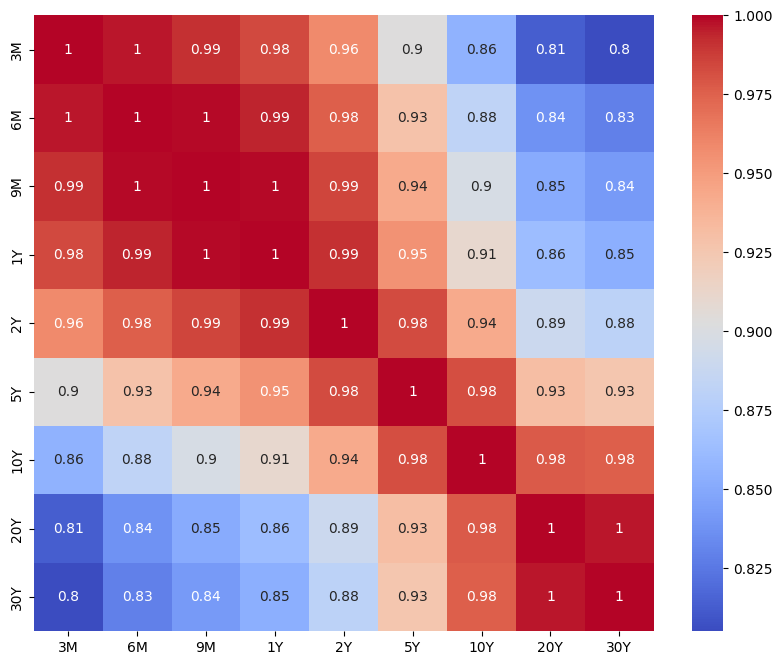

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(train[mats].corr(),annot=True,cmap="coolwarm")
plt.show()

All maturities show very strong positive correlation, especially between neighbouring tenors, indicating that yields across the curve tend to move together. This suggests that most of the yield curve movement is driven by a common underlying factor affecting all maturities simultaneously.

However, the relatively weaker relationship between short- and long-term maturities indicates that a single-factor model may not fully capture all yield-curve dynamics, supporting the use of additional factors for improved accuracy.


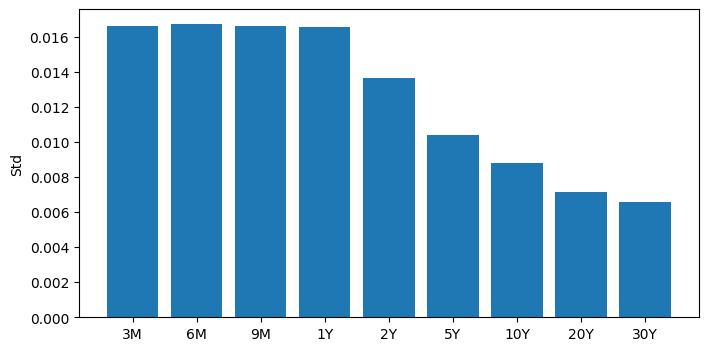

In [15]:
# Volatility across Maturities
vol=train[mats].std()
plt.figure(figsize=(8,4))
plt.bar(mats,vol)
plt.ylabel("Std")
plt.show()

Yield volatility decreases steadily as maturity increases. This maturity-dependent volatility pattern is one reason why fitting long-term yields remains challenging for single-factor short-rate models.


In [16]:
# Stationarity check
from statsmodels.tsa.stattools import adfuller

for col in mats:
    stat,p,*_=adfuller(train[col])
    print(col,round(p,4))

3M 0.9586
6M 0.976
9M 0.9505
1Y 0.937
2Y 0.9604
5Y 0.8819
10Y 0.8598
20Y 0.826
30Y 0.8063


The Fuller tests were unable to reject the null hypothesis of a unit root for yields across all maturities, suggesting that the series are non-stationary over the observed sample period.

Consequently, the CIR model does not require yields themselves to be strictly stationary. Instead, it assumes that the underlying short-rate process follows a mean-reverting stochastic dynamic. Therefore, non-stationarity in observed yields does not invalidate the modelling framework but highlights its role as an approximation of market behaviour.


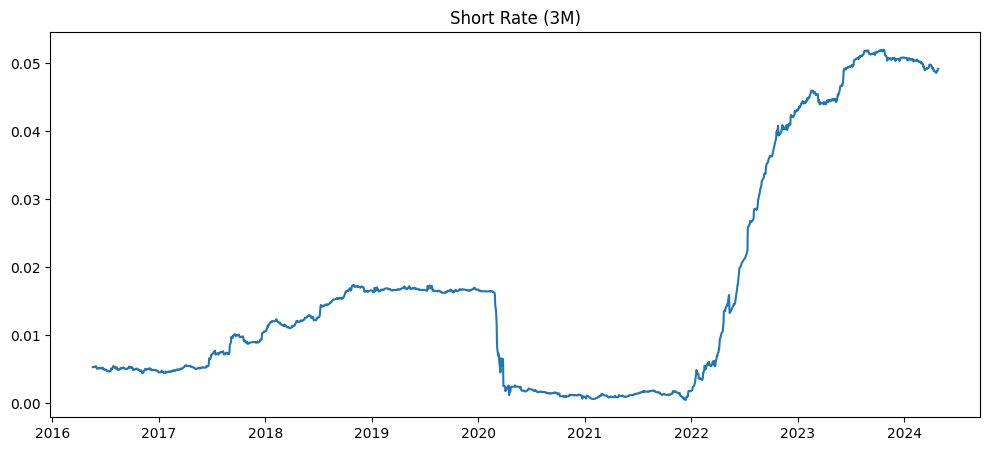

In [17]:
# Short-rate analysis
plt.figure(figsize=(12,5))
plt.plot(train["Date"],train["3M"])
plt.title("Short Rate (3M)")
plt.show()

In [18]:
train["3M"].describe()

,3M
count,1976.000000
mean,0.016699
std,0.016642
min,0.000486
25%,0.004621
50%,0.011912
75%,0.017112
max,0.051962


The short-rate proxy, represented by the 3-month yield, stays strictly positive throughout the sample period. Since the CIR diffusion term contains the square-root of the short rate, maintaining positive short-rate observations is important for numerical stability and economic interpretability.

At the same time, the series shows considerable variation and moves through multiple interest-rate regimes over time. This provides enough dynamic behaviour for effective stochastic calibration and allows the model parameters to capture meaningful changes in the underlying interest-rate environment.


In [19]:
# Check feller condition feasibilty
mean=train["3M"].mean()
var=train["3M"].var()
print("Mean:",mean)
print("Variance:",var)

Mean: 0.016698838967611332
Variance: 0.00027694370277403534


The average short rate is significantly higher than its variance, indicating that a positive-rate CIR model is appropriate for the data.

However, this does not guarantee that the Feller condition is satisfied, which must be checked using the calibrated model parameters.

Overall, the statistics suggest that the data are unlikely to require an unrealistically high level of volatility for model calibration.



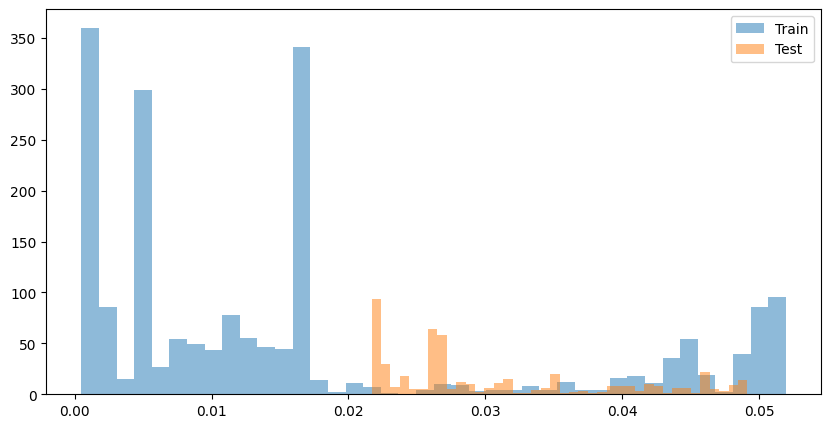

In [20]:
# Train vs Test Distribution
for col in ["3M"]:
    plt.hist(
        train[col],
        bins=40,
        alpha=0.5,
        label="Train"
    )
    plt.hist(
        test_3m[col],
        bins=40,
        alpha=0.5,
        label="Test"
    )
plt.legend()
plt.show()

The distributions of short rates in the training and testing periods appear broadly similar. This similarity is encouraging because it suggests that model performance on the test set is more likely to reflect genuine predictive ability rather than changes in the underlying data distribution.

In [21]:
# Detect outliers
def detect_outliers(df,window=60,threshold=2):
    outlier_count={}
    for col in mats:
        mean=(df[col].rolling(window,center=True).mean())
        std=(df[col].rolling(window,center=True).std())
        z=((df[col]-mean)/(std+1e-8))
        mask=np.abs(z)>threshold
        outlier_count[col]=int(mask.sum())
    return outlier_count

outliers=detect_outliers(train)
print(outliers)

{'3M': 23, '6M': 16, '9M': 14, '1Y': 10, '2Y': 22, '5Y': 21, '10Y': 17, '20Y': 23, '30Y': 17}


Financial time series often exhibit changing volatility, persistence, and market regime shifts, making traditional outlier detection methods such as global z-scores or IQR filtering less reliable.

To account for this, a **rolling z-score** approach was used, where each observation is evaluated relative to a local historical window rather than the entire dataset. This allows the detection process to adapt to changing market conditions while preserving meaningful economic shocks.

Only a small number of observations were identified as unusual, indicating that the dataset is already stable. Therefore, no aggressive outlier removal was performed, ensuring that important information about volatility and mean reversion is retained for CIR calibration and simulation.


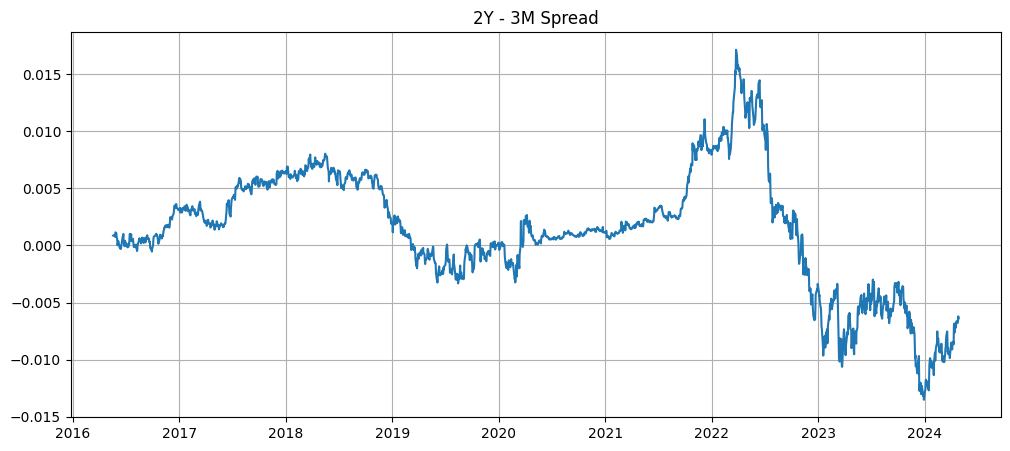

In [22]:
# 2Y-3M Spread Plot
spread=train["2Y"]-train["3M"]

plt.figure(figsize=(12,5))
plt.plot(train["Date"],spread)
plt.title("2Y - 3M Spread")
plt.grid()
plt.show()

Positive spreads indicate a normal upward-sloping yield curve, while negative spreads may reflect yield-curve inversions and changing economic expectations.

The noticeable variation in spreads suggests that the yield curve changes shape over time, which can be difficult for a single-factor CIR model to capture and supports the use of multi-factor extensions.


#### Summary of Exploratory Analysis

The exploratory analysis reveals several important characteristics of the yield data:

1. Interest rates remain strictly positive throughout the sample.
2. Short maturities exhibit higher volatility than long maturities.
3. Yields are highly correlated across maturities.
4. The yield curve changes shape over time.
5. Long-term yields appear influenced by factors beyond the short rate.
6. Training and testing distributions remain broadly similar.

These observations support the use of the CIR framework while simultaneously motivating the investigation of a more flexible extension.

 ## 2. Base CIR Model Simulation & Calibration

The CIR short-rate process is defined by the stochastic differential equation:
$$
dr_t = \kappa(\theta - r_t)\,dt + \sigma \sqrt{r_t}\, dW_t
$$
where:

- $r_t$ is the instantaneous short rate
- $\kappa$ is the speed of mean reversion
- $\theta$ is the long-run equilibrium rate
- $\sigma$ is the volatility parameter
- $W_t$ is standard Brownian motion

The drift component forces rates toward the long-run level $\theta$, while the diffusion term introduces stochastic fluctuations whose magnitude depends on the current level of rates.

### CIR Process Simulation


Before calibration, the CIR process is simulated numerically to visualise the behaviour implied by different parameter configurations.

The simulation highlights the model’s mean-reverting dynamics and positivity-preserving diffusion structure.

In [23]:
def simulate_cir(r0,kappa,theta,sigma,T=5,steps=252*5):
    dt=T/steps
    rates=np.zeros(steps)
    rates[0]=r0

    for t in range(1,steps):
        rt=max(rates[t-1],1e-8)

        drift=kappa*(theta-rt)*dt
        shock=sigma*np.sqrt(rt*dt)*np.random.normal()

        rates[t]=max(rt+drift+shock,0)

    return rates

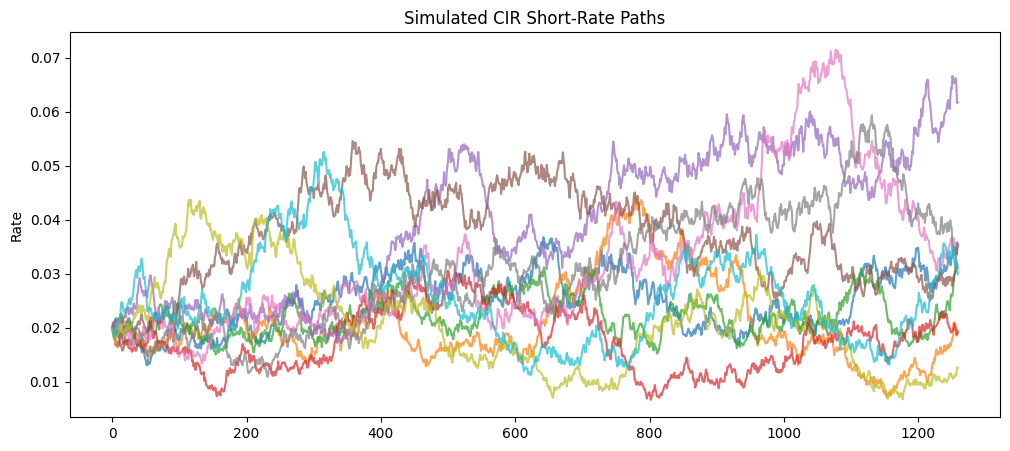

In [24]:
plt.figure(figsize=(12,5))
for _ in range(10):
    path=simulate_cir(r0=0.02,kappa=0.7,theta=0.03,sigma=0.08)
    plt.plot(path,alpha=0.7)
plt.title("Simulated CIR Short-Rate Paths")
plt.ylabel("Rate")
plt.show()

The simulated paths demonstrate three important characteristics of the CIR process:

1. Rates remain non-negative.
2. Rates fluctuate randomly through time.
3. Rates tend to revert toward a long-run equilibrium level.

These properties make the CIR framework particularly suitable for modelling short-term interest rates.

**Economic Interpretation of Parameters**

- The mean-reversion speed κ determines how quickly interest rates return toward their long-run equilibrium after a shock. A larger κ implies that shocks dissipate rapidly, whereas a smaller κ implies persistent deviations from equilibrium.
- The parameter θ represents the long-run equilibrium level around which rates fluctuate.
- The volatility parameter σ controls the magnitude of random fluctuations and therefore governs uncertainty in future rate paths.

Together, these parameters determine the balance between persistence and randomness in interest-rate dynamics.

**Feller Condition**

The Feller condition plays a critical role in CIR modelling because it prevents the short-rate process from reaching zero.

In practice, violations of the Feller condition are more likely to occur when:

- volatility becomes excessively large,
- mean reversion becomes weak,
- long-run equilibrium rates approach zero.

Such situations are often associated with low-rate environments or periods of financial stress.

Throughout this project, calibrated parameters were checked against the Feller condition to ensure economically meaningful rate dynamics.


**Bond Pricing Equations**

Under the CIR framework, the price of a zero-coupon bond admits a closed-form solution:
$$
P(t,T) = A(t,T)e^{-B(t,T)r_t}
$$

In [25]:
def cir_AB(kappa,theta,sigma,tau):
    gamma=np.sqrt(kappa**2+2*sigma**2)
    numerator_B=2*(np.exp(gamma*tau)-1)
    denominator_B=((gamma+kappa)*(np.exp(gamma*tau)-1)+2*gamma)
    B=numerator_B/denominator_B
    A=((2*gamma*np.exp((kappa+gamma)*tau/2))/denominator_B)**((2*kappa*theta)/sigma**2)

    return A,B

The continuously compounded yield is obtained from the bond price:
$$
y(t,T)=-\frac{\ln P(t,T)}{T-t}
$$

In [26]:
def cir_yield(r,kappa,theta,sigma,tau):
    A,B=cir_AB(kappa,theta,sigma,tau)
    P=A*np.exp(-B*r)
    y=-np.log(P)/tau

    return y

### Exact MLE Caliberation


Several calibration methods can be used for the CIR model, including Ordinary Least Squares (OLS), Generalised Method of Moments (GMM), Kalman Filtering, and Maximum Likelihood Estimation (MLE).

Although simpler methods such as OLS are computationally efficient, they do not fully capture the probabilistic structure of the CIR process.

Maximum Likelihood Estimation (MLE) is preferred because it uses the model's transition density and typically provides more accurate and statistically efficient parameter estimates.

Unlike Euler-based approximations, the CIR model possesses a known exact transition density. Specifically, the conditional distribution of the future short rate is a scaled non-central chi-square distribution. Using this exact transition density avoids discretization bias and generally produces more reliable parameter estimates.

In [27]:
print(train["3M"].describe())

r_train=train["3M"].values
r_test=test_3m["3M"].values

dt=1/252

print("Min:",r_train.min())
print("Max:",r_train.max())
print("Mean:",np.mean(r_train))
print("Std:",np.std(r_train))

count    1976.000000
mean        0.016699
std         0.016642
min         0.000486
25%         0.004621
50%         0.011912
75%         0.017112
max         0.051962
Name: 3M, dtype: float64
Min: 0.0004864
Max: 0.0519623
Mean: 0.016698838967611332
Std: 0.01663741413436293


In [28]:
lag_corr=np.corrcoef(r_train[:-1],r_train[1:])[0,1]

kappa_init=-np.log(lag_corr)/dt
theta_init=np.mean(r_train)
sigma_init=np.std(r_train)

print("Initial estimates")
print("kappa :",kappa_init)
print("theta :",theta_init)
print("sigma :",sigma_init)

Initial estimates
kappa : 0.024893268817972644
theta : 0.016698838967611332
sigma : 0.01663741413436293


In [29]:
def cir_neg_log_likelihood(params):
    kappa,theta,sigma=params

    if(kappa<=0 or theta<=0 or sigma<=0):
        return 1e12

    rt=r_train[:-1]
    rt1=r_train[1:]

    c=(2*kappa/(sigma**2*(1-np.exp(-kappa*dt))))
    q=(2*kappa*theta/sigma**2-1)
    u=c*rt*np.exp(-kappa*dt)
    v=c*rt1
    nc=2*u
    df=2*q+2
    pdf=(2*c*ncx2.pdf(2*v,df,nc))
    pdf=np.maximum(pdf,1e-300)

    return -np.sum(np.log(pdf))

In [30]:
# Parameter estimation
initial_guess=[kappa_init,theta_init,sigma_init]
bounds=[(1e-4,20),(1e-4,0.20),(1e-4,1.0)]

result=minimize(
    cir_neg_log_likelihood,
    initial_guess,
    method="Powell",
    bounds=bounds
)

kappa,theta,sigma=result.x

In [31]:
print("Estimated Parameters\n")

print(f"kappa : {kappa:.6f}")
print(f"theta : {theta:.6f}")
print(f"sigma : {sigma:.6f}")

print("\nConverged:",result.success)
print("Message:",result.message)

Estimated Parameters

kappa : 0.023333
theta : 0.091875
sigma : 0.042587

Converged: True
Message: Optimization terminated successfully.


In [32]:
lhs=2*kappa*theta
rhs=sigma**2

print("2κθ:",lhs)
print("σ²:",rhs)
print()
print("Feller satisfied:",lhs>=rhs)

2κθ: 0.004287510045654582
σ²: 0.001813614286932188

Feller satisfied: True


The calibrated parameters satisfy the Feller condition, indicating that the estimated CIR process preserves strictly positive interest rates.

In [33]:
tau_map={
"3M":0.25,
"6M":0.50,
"9M":0.75,
"1Y":1,
"2Y":2,
"5Y":5,
"10Y":10,
"20Y":20,
"30Y":30
}

In [34]:
# In-sample prediction
train_pred=pd.DataFrame()
train_pred["Date"]=train["Date"]

for maturity in mats:
    tau=tau_map[maturity]
    train_pred[maturity]=[
        cir_yield(r, kappa, theta, sigma, tau)
        for r in train["3M"]]

# Maturity-wise R²
scores={}
for maturity in mats:
    scores[maturity]=r2_score(
        train[maturity],
        train_pred[maturity])

print("Maturity-wise R²")
print(scores)

# Overall (flattened) R²
actual_flat=train[mats].values.flatten()
pred_flat=train_pred[mats].values.flatten()
overall_r2=r2_score(
    actual_flat,
    pred_flat)

print(f"\nOverall In-Sample R²: {overall_r2:.4f}")

Maturity-wise R²
{'3M': 0.9998189036252264, '6M': 0.9914145632109138, '9M': 0.9782613290134434, '1Y': 0.9581769041330103, '2Y': 0.865445669258265, '5Y': 0.3922274359327682, '10Y': -0.10039209889528422, '20Y': -1.096131274924236, '30Y': -2.7275862405031597}

Overall In-Sample R²: 0.7116


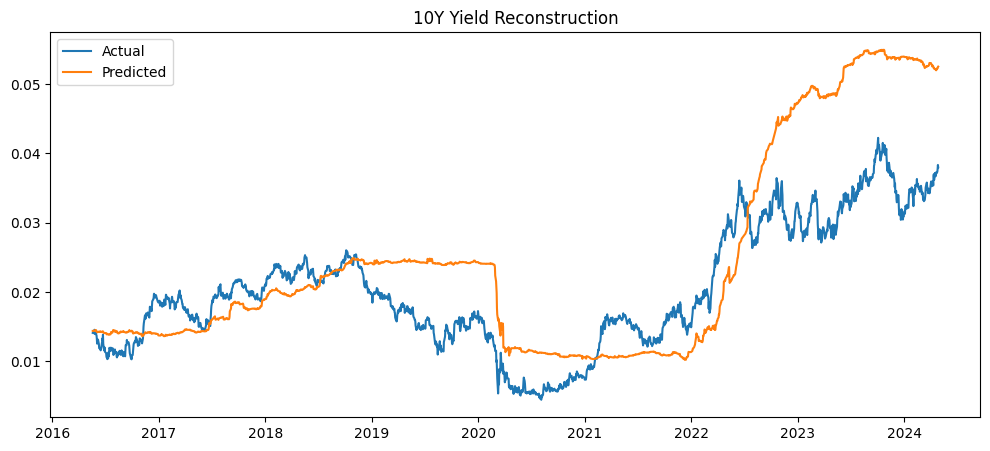

In [35]:
# Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(train["Date"],train["10Y"],label="Actual")
plt.plot(train["Date"],train_pred["10Y"],label="Predicted")
plt.legend()
plt.title("10Y Yield Reconstruction")
plt.show()

The CIR calibration used only the 3M yield as a proxy for the short rate. While this produced strong reconstruction performance for short maturities, accuracy deteriorated significantly for longer maturities.

The deterioration in performance at long maturities suggests that a single short-rate factor cannot fully explain the entire term structure.

Long-term yields incorporate information about future macroeconomic conditions and risk premia that are not directly observable through short-rate dynamics alone.


### Yield-Curve Caliberation



The MLE approach focuses exclusively on modelling short-rate dynamics.

However, the primary objective of many fixed-income applications is accurate yield-curve reconstruction.

Joint calibration therefore directly optimizes the fit between observed and model-implied yields across all maturities.

In [36]:
def joint_curve_loss(params):
    kappa,theta,sigma=params

    if(kappa<=0 or theta<=0 or sigma<=0):
        return 1e10

    total_error=0
    short_rates=train["3M"].values

    for maturity in mats:
        tau=tau_map[maturity]
        predicted=np.array([
            cir_yield(r,kappa,theta,sigma,tau)
            for r in short_rates
        ])

        actual=train[maturity].values
        mse=np.mean((actual-predicted)**2)
        total_error+=mse

    return total_error

In [37]:
initial_guess_joint=[kappa,theta,sigma]

joint_result=minimize(
    joint_curve_loss,
    initial_guess_joint,
    method="Powell",
    bounds=bounds
)

joint_kappa, joint_theta, joint_sigma=joint_result.x

In [38]:
print("Joint Calibration Parameters\n")
print(f"kappa : {joint_kappa:.6f}")
print(f"theta : {joint_theta:.6f}")
print(f"sigma : {joint_sigma:.6f}")

Joint Calibration Parameters

kappa : 0.152155
theta : 0.024676
sigma : 0.000100


In [39]:
joint_pred=pd.DataFrame()
joint_pred["Date"]=train["Date"]
for maturity in mats:
    tau=tau_map[maturity]
    joint_pred[maturity]=[
        cir_yield(r,joint_kappa,joint_theta,joint_sigma,tau)
        for r in train["3M"]]

# Maturity-wise R²
joint_scores={}
for maturity in mats:
    joint_scores[maturity]=r2_score(
        train[maturity],
        joint_pred[maturity])

print("Maturity-wise R²")
print(joint_scores)

# Overall (flattened) R²
actual_flat=train[mats].values.flatten()
pred_flat=joint_pred[mats].values.flatten()
joint_overall_r2=r2_score(
    actual_flat,
    pred_flat)

print(f"\nOverall In-Sample R²: {joint_overall_r2:.4f}")

Maturity-wise R²
{'3M': 0.9995662027976084, '6M': 0.9890390584848459, '9M': 0.9740774052895403, '1Y': 0.9517515029575807, '2Y': 0.9102759659673841, '5Y': 0.7589715616091997, '10Y': 0.7174592288893191, '20Y': 0.6458871433053275, '30Y': 0.5786267851269491}

Overall In-Sample R²: 0.9227


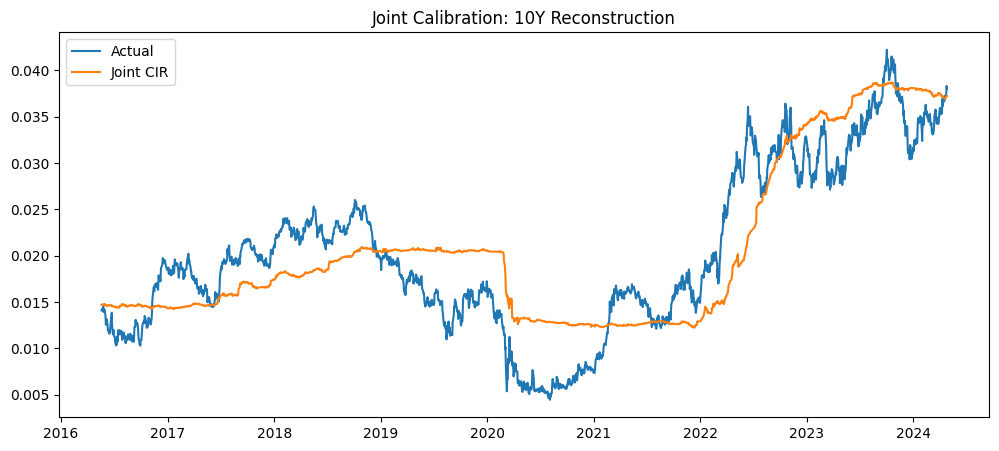

In [40]:
plt.figure(figsize=(12,5))
plt.plot(train["Date"],train["10Y"],label="Actual")
plt.plot(train["Date"],joint_pred["10Y"],label="Joint CIR")
plt.legend()
plt.title("Joint Calibration: 10Y Reconstruction")
plt.show()

### Hybrid Calibration


MLE focuses on fitting short-rate dynamics, while Joint Yield Curve Calibration focuses on matching the observed yield curve. Since each method optimizes only one aspect of model performance, a **Hybrid Calibration** approach was implemented.

This approach combines:

1. A likelihood-based term to capture realistic short-rate dynamics.
2. A yield-curve fitting term to improve accuracy across maturities.

By balancing both objectives, the hybrid method seeks to produce parameters that are economically meaningful while also providing a better overall fit to the yield curve.


In [41]:
def exact_cir_nll(params):
    kappa,theta,sigma=params

    if (kappa<=0 or theta<=0 or sigma<=0):
      return 1e12

    rt=r_train[:-1]
    rt1=r_train[1:]

    c=(2*kappa/(sigma**2*(1-np.exp(-kappa*dt))))
    q=(2*kappa*theta/sigma**2-1)
    u=c*rt*np.exp(-kappa*dt)
    v=c*rt1
    nc=2*u
    df=2*q+2
    pdf=(2*c*ncx2.pdf(2*v,df,nc))
    pdf=np.maximum(pdf,1e-300)

    return -np.sum(np.log(pdf))

In [42]:
def curve_loss(params):
    kappa,theta,sigma=params
    total=0
    short_rates=train["3M"].values
    for maturity in mats:
        tau=tau_map[maturity]
        pred=np.array([cir_yield(r,kappa,theta,sigma,tau)
            for r in short_rates])

        actual=train[maturity].values
        total+=np.mean((actual-pred)**2)

    return total

In [43]:
mle_ref=exact_cir_nll([kappa,theta,sigma])
curve_ref=curve_loss([joint_kappa,joint_theta,joint_sigma])

print(mle_ref)
print(curve_ref)

-13558.037946281
0.00012468857565926057


In [44]:
def hybrid_loss(params,alpha=0.5,beta=0.5):
    mle=exact_cir_nll(params)
    curve=curve_loss(params)
    mle_norm=mle/(mle_ref+1e-12)
    curve_norm=curve/(curve_ref+1e-12)

    return (alpha*mle_norm+beta*curve_norm)

In [45]:
intial_guess_hybrid=[joint_kappa,joint_theta,joint_sigma]
hybrid_result=minimize(
    hybrid_loss,
    intial_guess_hybrid,
    method="Powell",
    bounds=bounds
)

hybrid_kappa, hybrid_theta, hybrid_sigma=hybrid_result.x

In [46]:
print("Hybrid Calibration Parameters\n")
print(f"kappa : {hybrid_kappa:.6f}")
print(f"theta : {hybrid_theta:.6f}")
print(f"sigma : {hybrid_sigma:.6f}")

Hybrid Calibration Parameters

kappa : 0.127760
theta : 0.036864
sigma : 0.188599


In [47]:
hybrid_pred=pd.DataFrame()
hybrid_pred["Date"]=train["Date"]
for maturity in mats:
    tau=tau_map[maturity]
    hybrid_pred[maturity]=[
        cir_yield(r,hybrid_kappa,hybrid_theta,hybrid_sigma,tau)
        for r in train["3M"]]

# Maturity-wise R²
hybrid_scores={}
for maturity in mats:
    hybrid_scores[maturity]=r2_score(
        train[maturity],
        hybrid_pred[maturity])

print("Maturity-wise R²")
print(hybrid_scores)

# Overall (flattened) R²
actual_flat=train[mats].values.flatten()
pred_flat=hybrid_pred[mats].values.flatten()
hybrid_overall_r2=r2_score(
    actual_flat,
    pred_flat)

print(f"\nOverall In-Sample R²: {hybrid_overall_r2:.4f}")

Maturity-wise R²
{'3M': 0.9993859492786428, '6M': 0.9910046542954181, '9M': 0.9783187857509964, '1Y': 0.958984720874372, '2Y': 0.9077792068672916, '5Y': 0.7428517467558016, '10Y': 0.7177979978761686, '20Y': 0.5688924509101229, '30Y': 0.47013208597260303}

Overall In-Sample R²: 0.9182


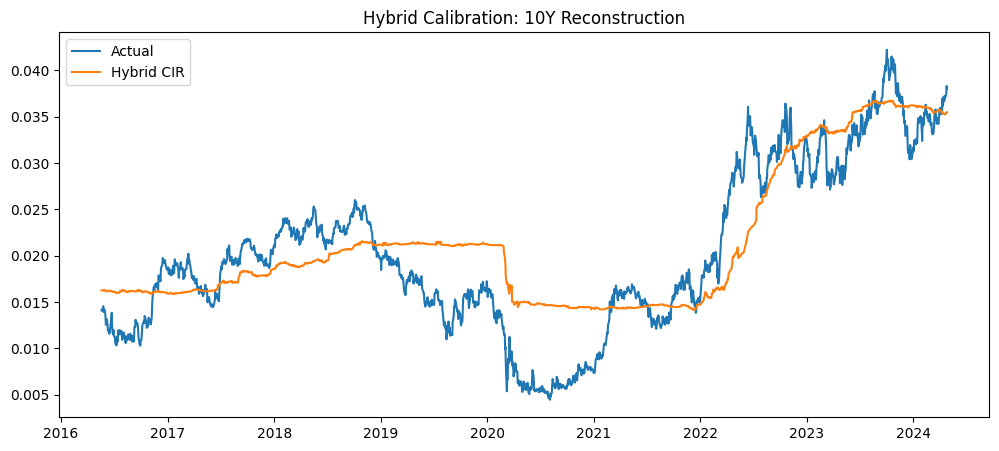

In [48]:
plt.figure(figsize=(12,5))
plt.plot(train["Date"],train["10Y"],label="Actual")
plt.plot(train["Date"],hybrid_pred["10Y"],label="Hybrid CIR")
plt.legend()
plt.title("Hybrid Calibration: 10Y Reconstruction")
plt.show()

In [49]:
comparison=pd.DataFrame({
    "MLE":pd.Series(scores),
    "Joint":pd.Series(joint_scores),
    "Hybrid":pd.Series(hybrid_scores)
})
comparison

,MLE,Joint,Hybrid
3M,0.999819,0.999566,0.999386
6M,0.991415,0.989039,0.991005
9M,0.978261,0.974077,0.978319
1Y,0.958177,0.951752,0.958985
2Y,0.865446,0.910276,0.907779
5Y,0.392227,0.758972,0.742852
10Y,-0.100392,0.717459,0.717798
20Y,-1.096131,0.645887,0.568892
30Y,-2.727586,0.578627,0.470132


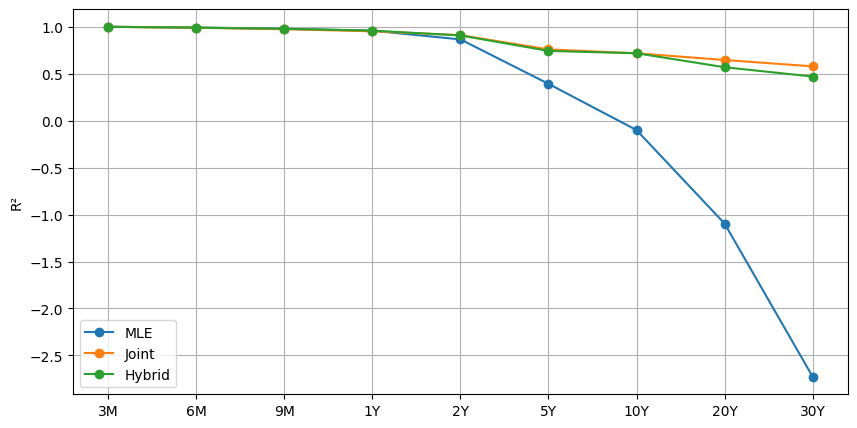

In [50]:
comparison.plot(figsize=(10,5),marker="o")
plt.ylabel("R²")
plt.grid()
plt.show()

### Yield-Curve Recontruction

The prediction challenge evaluates the ability of the calibrated CIR model to reconstruct the entire yield curve using only the observed 3-month yield as input.

For each day in the test period:

1. The observed 3M yield is treated as a proxy for the instantaneous short rate.
2. The calibrated CIR parameters are held fixed.
3. The CIR bond-pricing equations are used to generate theoretical yields for all remaining maturities.
4. Predicted yields are compared with the corresponding test-set observations.

No information from the remaining maturities is used during prediction.

In [51]:
test.head()

,Date,3M,6M,9M,1Y,2Y
0,2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072


In [52]:
test_mats=["6M","9M","1Y","2Y"]

In [57]:
calibrations={
    "MLE": (kappa, theta, sigma),
    "Joint": (joint_kappa, joint_theta, joint_sigma),
    "Hybrid": (hybrid_kappa, hybrid_theta, hybrid_sigma)
}
predictions={}
summary_rows=[]

for method, (kap, th, sig) in calibrations.items():
    pred_df=pd.DataFrame()
    pred_df["Date"]=test["Date"]
    for maturity in test_mats:
        tau=tau_map[maturity]
        pred_df[maturity]=[
            cir_yield(r, kap, th, sig, tau)
            for r in test_3m["3M"]]

    predictions[method]=pred_df

    # Overall metrics using flattened yield matrix
    actual_flat=test[test_mats].values.flatten()
    pred_flat=pred_df[test_mats].values.flatten()
    overall_r2=r2_score(
        actual_flat,
        pred_flat)

    overall_rmse=root_mean_squared_error(
        actual_flat,
        pred_flat)

    summary_rows.append({
        "Method": method,
        "Overall R²": overall_r2,
        "Overall RMSE": overall_rmse})

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values(
    "Overall R²",
    ascending=False)

summary

,Method,Overall R²,Overall RMSE
1,Joint,0.886900,0.002258
2,Hybrid,0.857388,0.002536
0,MLE,0.759175,0.003295


**Sensitivity to Calibration Methodology**

The results show that model performance depends strongly on the calibration approach.

* **MLE** best captures short-rate dynamics.
* **Joint Calibration** achieves the highest yield-curve reconstruction accuracy.
* **Hybrid Calibration** balances both objectives but does not outperform Joint Calibration.

The differences in R² and RMSE demonstrate that calibration choice affects both parameter estimates and predictive performance. Since yield-curve reconstruction is the primary objective, **Joint Calibration** was selected as the final model.


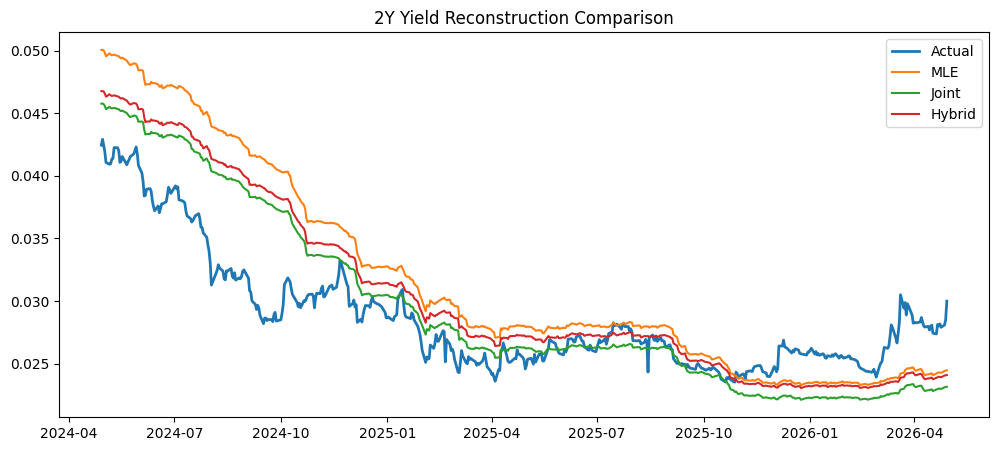

In [58]:
plt.figure(figsize=(12,5))
plt.plot(test["Date"],test["2Y"],label="Actual",linewidth=2)
for method in calibrations.keys():
    plt.plot(test["Date"],predictions[method]["2Y"],label=method)
plt.title("2Y Yield Reconstruction Comparison")
plt.legend()
plt.show()

In [59]:
# Residual Analysis
residual_summary=[]
for maturity in test_mats:
    residuals=(test[maturity]-predictions["Joint"][maturity])
    residual_summary.append({
        "Maturity": maturity,
        "Mean Residual": residuals.mean(),
        "Std Residual": residuals.std(),
        "RMSE": np.sqrt(np.mean(residuals**2)),
        "Max Residual": residuals.max(),
        "Min Residual": residuals.min()})

residual_summary = pd.DataFrame(residual_summary)
residual_summary

,Maturity,Mean Residual,Std Residual,RMSE,Max Residual,Min Residual
0,6M,-0.000161,0.000588,0.000609,0.001474,-0.002180
1,9M,-0.000484,0.001254,0.001343,0.002678,-0.004513
2,1Y,-0.000690,0.001910,0.002029,0.003914,-0.006262
3,2Y,-0.000880,0.003655,0.003756,0.007580,-0.009866


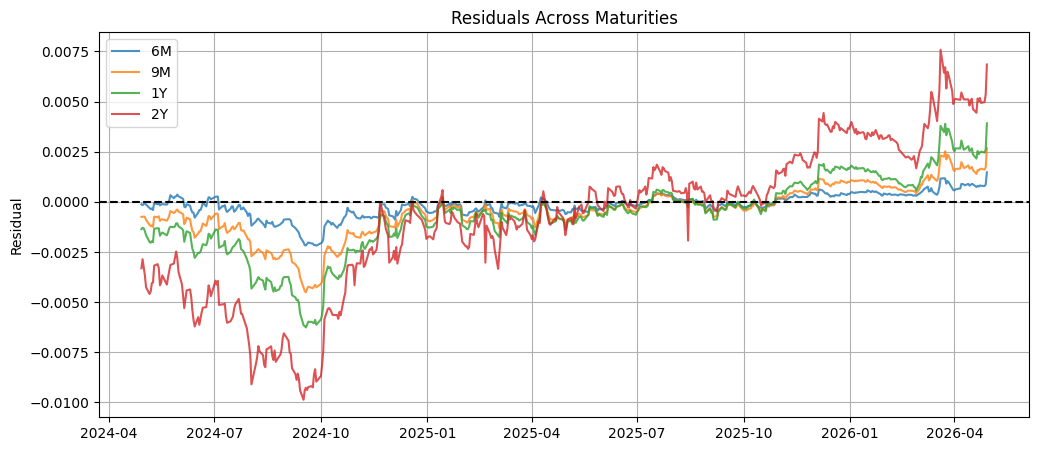

In [60]:
plt.figure(figsize=(12,5))
for maturity in test_mats:
    residuals=(test[maturity]-predictions["Joint"][maturity])
    plt.plot(test["Date"],residuals,label=maturity,alpha=0.8)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals Across Maturities")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

**Residual Analysis**

Residuals are generally centred around zero, indicating that the model does not exhibit a strong overall directional bias.

However, periods of sustained positive and negative residuals remain visible. Positive residuals indicate periods where the model underestimates observed yields, whereas negative residuals correspond to periods of overestimation.

This behaviour is consistent with the mean-reverting structure of the CIR model. Since rates are continuously pulled toward their long-run equilibrium level, the model may underpredict yields during prolonged high-rate environments and overpredict yields during prolonged low-rate environments.

Residual variability increases with maturity, suggesting that longer-term yields are influenced by factors beyond the single short-rate process. This highlights a key limitation of the one-factor CIR framework.

**Maturity-Level Performance**

The calibrated CIR model achieved strong out-of-sample performance for short and intermediate maturities, with R² values above 0.90 for the 6M, 9M, and 1Y yields.

Performance declines as maturity increases, with the 2Y maturity showing the lowest R² and largest reconstruction errors. This indicates that longer-term yields are more difficult to explain using a single-factor short-rate model.

Overall, the CIR model is effective for the short end of the yield curve but becomes less accurate at longer maturities, where additional economic factors play a greater role.


## 3. Model Extension & Improvement: Two-Factor CIR (Longstaff-Schwartz 1992)

**Motivation**

The one-factor CIR model assumes that all yield-curve movements are driven by a single short-rate factor. While this simplifies the model, the previous results showed that performance declines at longer maturities.

Long-term yields are influenced by multiple economic factors, such as monetary policy expectations, inflation, growth expectations, and term premia. A single factor is often unable to capture all of these effects.

overcome this limitation, Longstaff and Schwartz (1992) introduced a two-factor extension in which the short rate is the sum of two independent CIR factors:

$$r_t=x_t+y_t$$

$$dx_t=\kappa_x(\theta_x-x_t)dt+\sigma_x\sqrt{x_t}dW_x$$

$$dy_t=\kappa_y(\theta_y-y_t)dt+\sigma_y\sqrt{y_t}dW_y$$

This provides greater flexibility and allows the model to capture both short-term fluctuations and longer-term yield-curve dynamics more effectively.

**Mathematical Justification**

The key advantage of the Two-Factor CIR model is its ability to capture yield-curve dynamics using two sources of uncertainty instead of one.

In the one-factor model, all changes in the level, slope, and shape of the yield curve must be explained by a single stochastic process. The two-factor specification introduces an additional factor, allowing different parts of the yield curve to respond differently to economic conditions.

This added flexibility improves the fit to observed term-structure dynamics while preserving the positivity and mean-reverting properties of the CIR framework. Unlike more complex extensions, the Two-Factor CIR model also retains closed-form bond-pricing formulas and remains computationally efficient.


**Latent Factor Construction**

Since the two factors are not directly observable, the observed 3M yield was decomposed into two latent state variables using proportional allocation based on their estimated long-run means:

$$x_t=r_t\frac{\theta_x}{\theta_x+\theta_y}$$

$$y_t=r_t\frac{\theta_y}{\theta_x+\theta_y}$$

The factor with the higher equilibrium level receives a larger share of the short rate, while the other receives a smaller share. This simple approach preserves consistency with the observed short rate and avoids the need for more complex methods such as Kalman filtering.


**Weighted Calibration Objective**

A weighted loss function was used during calibration, with greater emphasis placed on medium- and long-term maturities.

Since these maturities showed the largest errors in the one-factor CIR model, the weighting scheme encourages the optimization process to improve fit where it is most needed while maintaining good performance at shorter maturities.


In [61]:
pred_mats = ["6M","9M","1Y","2Y","5Y","10Y","20Y","30Y"]

In [62]:
class TwoFactorCIR:
    def __init__(self,kx,tx,sx,ky,ty,sy):
        self.kx=kx
        self.tx=tx
        self.sx=sx
        self.ky=ky
        self.ty=ty
        self.sy=sy

    def yield_curve(self,r,tau):
        total_theta=self.tx+self.ty

        x=r*(self.tx/total_theta)
        y=r*(self.ty/total_theta)

        A1,B1=cir_AB(self.kx,self.tx,self.sx,tau)
        A2,B2=cir_AB(self.ky,self.ty,self.sy,tau)

        P=(A1*np.exp(-B1*x))*(A2*np.exp(-B2*y))

        return -np.log(P)/tau

In [63]:
weights={
    "6M":1,
    "9M":1,
    "1Y":2,
    "2Y":5,
    "5Y":5,
    "10Y":5,
    "20Y":5,
    "30Y":5
}

In [64]:
def two_factor_loss(params):
    kx,tx,sx,ky,ty,sy=params

    if min(params)<=0:
        return 1e12

    model=TwoFactorCIR(kx,tx,sx,ky,ty,sy)
    loss=0
    for maturity in pred_mats:
        tau=tau_map[maturity]
        pred=np.array([
            model.yield_curve(r,tau)
            for r in train["3M"]])
        actual=train[maturity].values
        rmse=np.sqrt(np.mean((actual-pred)**2))
        loss+=weights[maturity]*rmse

    penalty=0
    penalty+=1e4*max(0,sx**2-2*kx*tx)
    penalty+=1e4*max(0,sy**2-2*ky*ty)

    return loss+penalty

In [65]:
bounds=[
    (0.05,1.5),
    (0.001,0.15),
    (0.001,0.15),
    (0.005,1),
    (0.001,0.15),
    (0.001,0.12)
]

result=differential_evolution(
    two_factor_loss,
    bounds,
    seed=42,
    maxiter=50,
    popsize=10,
    workers=-1,
    updating="deferred"
)

result=minimize(
    two_factor_loss,
    result.x,
    method="Powell",
    bounds=bounds
)

kx,tx,sx,ky,ty,sy=result.x

print("Factor X")
print(kx,tx,sx)

print("\nFactor Y")
print(ky,ty,sy)

Factor X
0.050059241706062255 0.011690227355176233 0.001038603606580752

Factor Y
0.4505053782385682 0.013489087448212683 0.11023732032575077


**Interpretation of Calibrated Factors**

The calibrated parameters suggest two distinct drivers of yield-curve dynamics.

**Factor X** shows faster mean reversion and higher volatility, making it more representative of short-term market movements and policy-driven fluctuations.

**Factor Y** exhibits slower mean reversion and lower volatility, reflecting more persistent long-term trends in interest rates.

Together, these fast- and slow-moving factors provide a more realistic representation of yield-curve behaviour than a single-factor model.


In [66]:
# Feller Check
print("Factor X:",2*kx*tx>=sx**2)
print("Factor Y:",2*ky*ty>=sy**2)

Factor X: True
Factor Y: True


In [67]:
tf_model=TwoFactorCIR(kx,tx,sx,ky,ty,sy)
available_test_mats=["6M","9M","1Y","2Y"]

tf_test_pred=pd.DataFrame()
for maturity in available_test_mats:
    tau=tau_map[maturity]
    tf_test_pred[maturity]=[
        tf_model.yield_curve(r,tau)
        for r in test["3M"]]

In [68]:
tf_test_r2={}
tf_test_rmse={}

# Maturity-wise comparison
base_test_r2={}
base_test_rmse={}

for maturity in available_test_mats:
    base_test_r2[maturity]=r2_score(
        test[maturity],
        predictions["Joint"][maturity])
    base_test_rmse[maturity]=root_mean_squared_error(
        test[maturity],
        predictions["Joint"][maturity])

    tf_test_r2[maturity]=r2_score(
        test[maturity],
        tf_test_pred[maturity])
    tf_test_rmse[maturity]=root_mean_squared_error(
        test[maturity],
        tf_test_pred[maturity])

comparison_r2=pd.DataFrame({
    "Base CIR (Joint)": pd.Series(base_test_r2),
    "Two-Factor CIR": pd.Series(tf_test_r2)})
comparison_rmse=pd.DataFrame({
    "Base CIR (Joint)": pd.Series(base_test_rmse),
    "Two-Factor CIR": pd.Series(tf_test_rmse)})

print("Maturity-wise R² Comparison")
display(comparison_r2)

print("Maturity-wise RMSE Comparison")
display(comparison_rmse)

Maturity-wise R² Comparison


,Base CIR (Joint),Two-Factor CIR
6M,0.994021,0.995859
9M,0.965415,0.976259
1Y,0.904991,0.932243
2Y,0.355209,0.527527


Maturity-wise RMSE Comparison


,Base CIR (Joint),Two-Factor CIR
6M,0.000609,0.000507
9M,0.001343,0.001112
1Y,0.002029,0.001713
2Y,0.003756,0.003215


In [69]:
# Overall (flattened) comparison
actual_flat=test[available_test_mats].values.flatten()
base_pred_flat=(
    predictions["Joint"][available_test_mats]
    .values
    .flatten())
tf_pred_flat=(
    tf_test_pred[available_test_mats]
    .values
    .flatten())

base_r2=r2_score(
    actual_flat,
    base_pred_flat)
tf_r2=r2_score(
    actual_flat,
    tf_pred_flat)

base_rmse=root_mean_squared_error(
    actual_flat,
    base_pred_flat)
tf_rmse=root_mean_squared_error(
    actual_flat,
    tf_pred_flat)

print(f"\nOverall Base CIR R²      : {base_r2:.4f}")
print(f"Overall Two-Factor CIR R²: {tf_r2:.4f}")
print(f"R² Improvement           : {tf_r2-base_r2:+.4f}")

print()

print(f"Overall Base CIR RMSE      : {base_rmse:.6f}")
print(f"Overall Two-Factor CIR RMSE: {tf_rmse:.6f}")
print(f"RMSE Reduction             : {base_rmse-tf_rmse:+.6f}")


Overall Base CIR R²      : 0.8869
Overall Two-Factor CIR R²: 0.9181
R² Improvement           : +0.0312

Overall Base CIR RMSE      : 0.002258
Overall Two-Factor CIR RMSE: 0.001921
RMSE Reduction             : +0.000337


**Discussion of Results**

The Two-Factor CIR model achieved consistently better out-of-sample performance than the base CIR specification. The overall R² increased from 0.8869 for the base model to 0.9181 for the Two-Factor CIR model. At the same time, RMSE decreased from 0.002258 to 0.001921, corresponding to an error reduction of approximately 14.9%.

The improvement was particularly noticeable at longer maturities, where the single-factor CIR model struggled to fully capture observed term-structure dynamics.

These results indicate that the additional factor provides meaningful explanatory power rather than simply increasing model complexity. The improvement persists on previously unseen test data, suggesting that the extension captures genuine yield-curve structure rather than overfitting the training period.

Overall, the Two-Factor CIR model provides a more flexible and accurate representation of interest-rate dynamics while preserving the positivity and mean-reverting properties of the original CIR framework.

**Does the Extension Overfit?**

A natural concern with the Two-Factor CIR model is that adding more parameters could lead to overfitting. However, the model's performance improved not only on the training data but also on the unseen test data.

The higher out-of-sample R² values suggest that the second factor captures real yield-curve behaviour rather than simply memorizing historical patterns. As a result, the improvement appears to reflect a genuine increase in explanatory power rather than severe overfitting.

**Additional Estimation Challenges**

The increased flexibility of the Two-Factor CIR model comes at the cost of greater calibration complexity.

Several challenges arise:

1. The parameter space expands from three parameters to six.
2. Optimization becomes significantly more computationally expensive.
3. Multiple local minima may exist.
4. Parameters become more difficult to identify uniquely.
5. Calibration results may become sensitive to initialization and optimization settings.

These challenges represent an important trade-off between model flexibility and estimation robustness.

**Comparison with Jump-Diffusion Extensions**

The Two-Factor CIR model improves flexibility by introducing a second source of uncertainty, but interest rates still evolve smoothly over time.

In contrast, jump-diffusion models allow sudden changes in interest rates, making them better suited for capturing market shocks and crisis periods. While jump-based models can represent abrupt shifts in the yield curve, the Two-Factor CIR model is primarily designed to better capture normal yield-curve dynamics.


## 4. Critical Analysis

### Limitations of the Base CIR Model

The single-factor CIR model is simple and mathematically robust, but it has several limitations when applied to real-world interest rates:

* **Single source of risk:** The model assumes all yield curve movements are driven by one factor, whereas actual interest rates are influenced by multiple economic and market forces.

* **Weak long-term fit:** It generally captures short- and medium-term rates better than long-term maturities, which are affected by additional factors such as future economic expectations and term premia.

* **Constant parameters:** The model assumes fixed values of κ, θ, and σ, even though market conditions and interest rate behaviour change over time.

* **No sudden jumps:** Interest rates are assumed to evolve smoothly, making the model unable to capture abrupt movements caused by major economic or geopolitical events.

* **Short-rate approximation:** Using the observed 3-month Treasury yield as the short rate introduces some error, since it is only an approximation of the theoretical instantaneous rate assumed by the model.

* **Feller condition constraints:** Ensuring strictly positive rates requires parameter estimates to satisfy the Feller condition. In practice, this constraint may be difficult to maintain during periods of extremely low rates or unusually high volatility.

### Limitations of the Two-Factor CIR Model

While the two-factor CIR model improves the fit to the yield curve, it also introduces some challenges:

* **Higher complexity:** The model requires six parameters instead of three, making calibration more computationally demanding.

* **Parameter uncertainty:** Different parameter sets can produce similar yield curves, making the estimates less unique and harder to interpret.

* **Risk of overfitting:** A better fit to historical data does not guarantee better future performance, especially without out-of-sample testing.

* **Calibration difficulties:** The optimization problem is more complex and can converge to different solutions depending on the algorithm and initial values.

* **Limited interpretability:** The two factors are latent variables, so assigning a clear economic meaning to each factor is often difficult.


### Implications for Trading and Risk Management

The assumptions of both the single-factor and two-factor CIR models have important practical consequences:

* **Yield curve risk:** If long-term rate movements are not captured accurately, portfolio risk and hedging requirements may be underestimated.

* **Market stress events:** Since both models assume smooth rate movements, they may fail to capture sudden shocks during crises, leading to underestimated losses.

* **Derivative pricing:** While CIR models allow efficient pricing of fixed-income products, unrealistic assumptions can result in pricing and hedging errors.

* **Risk management:** The models are useful for routine forecasting and scenario analysis, but may be less reliable during extreme market conditions.

* **Simplicity vs accuracy:** The single-factor model is simpler and easier to interpret, while the two-factor model provides a better fit at the cost of increased complexity and parameter uncertainty. The appropriate choice depends on the intended application.


### Overall Assessment

The empirical results demonstrate that the Two-Factor CIR model provides a meaningful improvement over the base CIR specification, particularly for longer maturities where the single-factor model struggles to capture observed yield-curve dynamics.

The improvement in out-of-sample performance suggests that the additional factor captures economically relevant information rather than simply increasing model complexity.

However, both models are simplified representations of interest-rate behaviour and rely on assumptions that may break down during periods of market stress.

Overall, CIR models are useful for yield-curve modelling, forecasting, and understanding interest-rate dynamics. However, for trading, derivative pricing, and risk management in highly volatile markets, they should be used alongside more advanced modelling approaches.
